# Baselines, intervalos de confianza y efecto de la partición

Evaluación del sistema de traducción automática **qom ↔ español** (tesis de maestría,
FCEN-UBA). Los modelos son fine-tunes de `facebook/nllb-200-distilled-600M` sobre el
corpus paralelo QomL'aqtaq, con la etiqueta `grn_Latn` (guaraní) como **proxy** para qom
y `spa_Latn` para español.

### De dónde salen los datos

- **`data/predictions/`** — una carpeta por sistema. Cada carpeta trae
  `preds_qom2es_test.csv`, `preds_es2qom_test.csv` (columnas `id, source, reference,
  prediction`) y `metrics_test.csv` (métricas a nivel corpus en formato largo, con la
  grilla de chrF y columnas `direction, model, split, n, metric, word_order, beta, score,
  char_order`).
- **`data/qomL-hf/`** — el corpus empaquetado para Hugging Face (parquet por config y
  split, columnas `id, source, qom, es`). De acá salen los **train sets** para el chequeo
  de contaminación (1.1).

### Sistemas del estudio

| Alias | Carpeta de predicciones | Config qomL-hf (train) | Partición |
|---|---|---|---|
| `nllb-base` | `nllb-200-distilled-600M` | — (zero-shot) | — |
| `qom-mt-biblia` | `qom-mt-bible` | `bible-strat` | aleatoria |
| `qom-mt-v1-estratificado` | `qom-mt-v1-strat` | `v1-strat` | estratificada |
| `qom-mt-v1-aleatorio` | `qom-mt-v1-nostrat` | `v1-nostrat` | aleatoria |
| `qom-mt-v2-estratificado` | `qom-mt-v2-strat` | `v2-strat` | estratificada |
| `qom-mt-v2-aleatorio` | `qom-mt-v2-nostrat` | `v2-nostrat` | aleatoria |

### _Test set_ común

Todas las evaluaciones usan **el test estratificado de QomL-Base** (config `v1-strat`,
split `test`), en ambas direcciones (`qom2es` y `es2qom`). Es la única forma de comparar
sistemas entrenados sobre corpus distintos. **No** se usan los test sets propios de cada
modelo (p. ej. la carpeta `qomL-v2-nostrat` con el test de 3273 pares queda **excluida**).

### Estructura

- **Paso 0** — Inventario de lo que ya existe (+ bloque condicional de generación).
- **1.1** — Chequeo de contaminación train/test.
- **1.2** — Métricas a nivel corpus (recalculadas) + chrF++ por segmento.
- **1.3** — Intervalos de confianza (bootstrap pareado + test de permutación).
- **1.4** — Figuras y tablas de salida.

## Celda de configuración

Las rutas apuntan a la estructura del repo (`data/predictions`, `data/qomL-hf`).

El registro `SISTEMAS` mapea cada alias a su carpeta de predicciones y a la config
de qomL-hf para el train.

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd

# ── Reproducibilidad ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR    = Path("data")                    # raíz de datos (data/ del repo)
PRED_DIR    = DATA_DIR / "predictions"        # carpeta por sistema con preds + metrics
QOML_HF_DIR = DATA_DIR / "qomL-hf"            # corpus HF (parquet) para train sets

RESULTS_DIR = Path("data/results")              # CSV de salida (uno por resultado numérico)
FIG_DIR     = Path("poster/figures")       # figuras para el póster
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# chrF++ por segmento y tabla tidy de traducciones: los consume 1.3 y la Notebook 2.
SEGMENT_CHRF_CSV = RESULTS_DIR / "chrf_por_segmento.csv"
TIDY_CSV         = RESULTS_DIR / "traducciones_tidy.csv"

# ── Registro de sistemas: alias -> (carpeta_predicciones, config_qomL_hf | None) ──
SISTEMAS = {
    "nllb-base":               ("nllb-200-distilled-600M", None),          # zero-shot
    "qom-mt-biblia":           ("qom-mt-bible",            "bible-strat"),
    "qom-mt-v1-estratificado": ("qom-mt-v1-strat",         "v1-strat"),
    "qom-mt-v1-aleatorio":     ("qom-mt-v1-nostrat",       "v1-nostrat"),
    "qom-mt-v2-estratificado": ("qom-mt-v2-strat",         "v2-strat"),
    "qom-mt-v2-aleatorio":     ("qom-mt-v2-nostrat",       "v2-nostrat"),
}
SISTEMAS_ORDEN = list(SISTEMAS)

# Carpetas a ignorar dentro de data/predictions: test propio del modelo
# Solo se usan las del test común
EXCLUIR_CARPETAS = {"qomL-v2-nostrar-test", "qomL-v2-nostrat-test", "qomL-v2-nostrat"}

# Nombres de archivo dentro de cada carpeta de sistema.
PREDS_FILES  = {"qom2es": "preds_qom2es_test.csv", "es2qom": "preds_es2qom_test.csv"}
METRICS_FILE = "metrics_test.csv"
SPLIT_LABEL  = "estratificado"      # el test común es el estratificado de Base (v1-strat/test)

# ── Parámetros de generación (idénticos a los ya usados) ──────────────────────
# Sólo se usan si se activa el bloque condicional de generación del Paso 0.
GEN_PARAMS = dict(num_beams=4, no_repeat_ngram_size=3, max_new_tokens=128)
LANG = {"qom": "grn_Latn", "es": "spa_Latn"}
DIRECTION_LANGS = {"qom2es": ("qom", "es"), "es2qom": ("es", "qom")}

# ── Constantes del análisis ───────────────────────────────────────────────────
N_BOOTSTRAP     =  100       # réplicas del bootstrap (1.3)
N_PERMUTACIONES =  100       # permutaciones del test pareado (1.3)
SIM_UMBRAL      = 0.85       # umbral de similitud coseno para casi-duplicados (1.1)

print("Config cargada.")
print(f"  RANDOM_STATE   = {RANDOM_STATE}")
print(f"  predicciones   : {PRED_DIR.resolve()}")
print(f"  corpus qomL-hf : {QOML_HF_DIR.resolve()}")
print(f"  salidas        : {RESULTS_DIR.resolve()}")
print(f"  figuras        : {FIG_DIR.resolve()}")

Config cargada.
  RANDOM_STATE   = 42
  predicciones   : /home/macarena/Projects/personal/tesis/poster-evaluation-metrics-for-qom-esp-mt/data/predictions
  corpus qomL-hf : /home/macarena/Projects/personal/tesis/poster-evaluation-metrics-for-qom-esp-mt/data/qomL-hf
  salidas        : /home/macarena/Projects/personal/tesis/poster-evaluation-metrics-for-qom-esp-mt/data/results
  figuras        : /home/macarena/Projects/personal/tesis/poster-evaluation-metrics-for-qom-esp-mt/poster/figures


## Paso 0 — Inventario de lo que ya existe

Cargamos las predicciones de cada carpeta de sistema y armamos una tabla *tidy* con las
columnas canónicas (`segment_id, direction, system, split, source, reference, hypothesis`).
No asumimos nombres de columna: verificamos que cada CSV tenga las esperadas y fallamos con
un mensaje claro si no.

In [2]:
COLS_PREDS = ["id", "source", "reference", "prediction"]

def cargar_preds(folder, direccion):
    ruta = folder / PREDS_FILES[direccion]
    if not ruta.exists():
        return None
    df = pd.read_csv(ruta)
    faltan = [c for c in COLS_PREDS if c not in df.columns]
    if faltan:
        raise ValueError(f"{ruta} no tiene las columnas {faltan}. Tiene: {list(df.columns)}")
    out = df.rename(columns={"id": "segment_id", "prediction": "hypothesis"}).copy()
    out["direction"] = direccion
    out["split"] = SPLIT_LABEL
    return out[["segment_id", "direction", "source", "reference", "hypothesis", "split"]]

In [3]:
# ── Descubrir carpetas de sistema y cargar todas las predicciones ─────────────
if not PRED_DIR.exists():
    raise FileNotFoundError(
        f"No existe {PRED_DIR.resolve()}. Bajá las carpetas de predicciones a data/predictions/.")

piezas = []
sistemas_presentes = {}   # alias -> folder
for alias, (carpeta, _cfg) in SISTEMAS.items():
    folder = PRED_DIR / carpeta
    if carpeta in EXCLUIR_CARPETAS:
        continue
    if not folder.exists():
        print(f"[falta] {alias}: no está la carpeta {folder} -> se saltea.")
        continue
    trozos_sys = []
    for direccion in PREDS_FILES:
        p = cargar_preds(folder, direccion)
        if p is None:
            print(f"[aviso] {alias}: falta {PREDS_FILES[direccion]} en {folder}.")
            continue
        p["system"] = alias
        trozos_sys.append(p)
    if trozos_sys:
        piezas.extend(trozos_sys)
        sistemas_presentes[alias] = folder

if not piezas:
    raise FileNotFoundError(
        "No cargué ninguna predicción. Revisá que data/predictions/<carpeta>/preds_*.csv existan.")

tr = pd.concat(piezas, ignore_index=True)
tr = tr[["segment_id", "direction", "system", "split", "source", "reference", "hypothesis"]]
for c in ["source", "reference", "hypothesis"]:
    tr[c] = tr[c].astype("string")
tr.to_csv(TIDY_CSV, index=False)
print(f"\nPredicciones cargadas: {tr.shape[0]} filas | sistemas: {sorted(sistemas_presentes)}")
print(f"Tabla tidy -> {TIDY_CSV}")


Predicciones cargadas: 4632 filas | sistemas: ['nllb-base', 'qom-mt-biblia', 'qom-mt-v1-aleatorio', 'qom-mt-v1-estratificado', 'qom-mt-v2-aleatorio', 'qom-mt-v2-estratificado']
Tabla tidy -> data/results/traducciones_tidy.csv


In [4]:
# ── Inventario: sistemas, direcciones, conteos e ids comunes ──────────────────
print("Sistemas presentes :", sorted(tr["system"].unique()))
print("Direcciones        :", sorted(tr["direction"].unique()))

conteo = (tr.groupby(["system", "direction"]).size()
            .rename("n_segmentos").reset_index().sort_values(["system", "direction"]))
print("\nSegmentos por sistema x dirección:")
print(conteo.to_string(index=False))
conteo.to_csv(RESULTS_DIR / "inventario_conteos.csv", index=False)

# ¿Comparten el mismo test (mismos segment_id) todos los sistemas, por dirección?
# Queremos que sí porque queremos testear todos los sistemas con el mismo conjunto
N_COMUN = {}
for direccion in sorted(tr["direction"].unique()):
    sub = tr[tr["direction"] == direccion]
    sets = {s: set(g["segment_id"]) for s, g in sub.groupby("system")}
    comun = set.intersection(*sets.values()) if sets else set()
    N_COMUN[direccion] = len(comun)
    print(f"\n[{direccion}] ids comunes a todos los sistemas: {len(comun)}")
    for s, ids in sets.items():
        fuera = len(ids) - len(comun)
        if fuera:
            print(f"    {s}: {len(ids)} ids ({fuera} fuera del conjunto común)")

Sistemas presentes : ['nllb-base', 'qom-mt-biblia', 'qom-mt-v1-aleatorio', 'qom-mt-v1-estratificado', 'qom-mt-v2-aleatorio', 'qom-mt-v2-estratificado']
Direcciones        : ['es2qom', 'qom2es']

Segmentos por sistema x dirección:
                 system direction  n_segmentos
              nllb-base    es2qom          386
              nllb-base    qom2es          386
          qom-mt-biblia    es2qom          386
          qom-mt-biblia    qom2es          386
    qom-mt-v1-aleatorio    es2qom          386
    qom-mt-v1-aleatorio    qom2es          386
qom-mt-v1-estratificado    es2qom          386
qom-mt-v1-estratificado    qom2es          386
    qom-mt-v2-aleatorio    es2qom          386
    qom-mt-v2-aleatorio    qom2es          386
qom-mt-v2-estratificado    es2qom          386
qom-mt-v2-estratificado    qom2es          386

[es2qom] ids comunes a todos los sistemas: 386

[qom2es] ids comunes a todos los sistemas: 386


In [5]:
from sacrebleu.metrics import CHRF, BLEU

# ── Métricas a nivel corpus ya existentes (formato largo) ─────────────────────
# Extraemos, por sistema y dirección: BLEU y chrF++ (word_order=2, beta=2, char_order=6).
# Usamos las columnas numéricas (no el string 'metric', que varía entre archivos:
# 'chrF++ (beta=2)' vs 'chrF++ (β=2)').
def cargar_metricas(folder, alias):
    m = pd.read_csv(folder / METRICS_FILE)
    m.columns = [c.strip().lower() for c in m.columns]
    for c in ["word_order", "beta", "char_order", "score", "n"]:
        if c in m.columns:
            m[c] = pd.to_numeric(m[c], errors="coerce")
    filas = []
    for direccion, g in m.groupby("direction"):
        es_bleu = g["metric"].astype(str).str.upper().str.startswith("BLEU")
        bleu = g.loc[es_bleu, "score"]
        chrfpp = g[(g["word_order"] == 2) & (g["beta"] == CHRF.BETA) &
                   (g["char_order"] == CHRF.CHAR_ORDER)]["score"]
        filas.append({
            "system": alias, "direction": direccion, "split": SPLIT_LABEL,
            "bleu_agregado": float(bleu.iloc[0]) if len(bleu) else np.nan,
            "chrf_pp_agregado": float(chrfpp.iloc[0]) if len(chrfpp) else np.nan,
            "n_agregado": int(g["n"].dropna().iloc[0]) if g["n"].notna().any() else np.nan,
        })
    return pd.DataFrame(filas)

trozos_m = []
for alias, folder in sistemas_presentes.items():
    if not (folder / METRICS_FILE).exists():
        print(f"[aviso] {alias}: sin {METRICS_FILE}.")
        continue
    trozos_m.append(cargar_metricas(folder, alias))

metricas_agregadas = (pd.concat(trozos_m, ignore_index=True) if trozos_m
                      else pd.DataFrame(columns=["system", "direction", "split",
                                                 "bleu_agregado", "chrf_pp_agregado",
                                                 "n_agregado"]))
print(metricas_agregadas.to_string(index=False))

                 system direction         split  bleu_agregado  chrf_pp_agregado  n_agregado
              nllb-base    es2qom estratificado           1.63              9.38         386
              nllb-base    qom2es estratificado           0.84             11.03         386
          qom-mt-biblia    es2qom estratificado           1.28             27.95         386
          qom-mt-biblia    qom2es estratificado           2.09             19.24         386
qom-mt-v1-estratificado    es2qom estratificado           4.47             29.16         386
qom-mt-v1-estratificado    qom2es estratificado           5.22             20.40         386
    qom-mt-v1-aleatorio    es2qom estratificado          16.37             40.34         386
    qom-mt-v1-aleatorio    qom2es estratificado          13.18             30.32         386
qom-mt-v2-estratificado    es2qom estratificado           6.44             34.87         386
qom-mt-v2-estratificado    qom2es estratificado           8.64        

### Sobre el chrF++ del CSV agregado

El `metrics_test.csv` trae la grilla completa de sacrebleu con las columnas numéricas
`word_order`, `beta` y `char_order`. El **chrF++** comparable con la literatura es el de
`word_order=2, beta=2, char_order=6` (equivalente a `sacrebleu.CHRF(word_order=2)`), y está
identificado sin ambigüedad por esas columnas. Por eso el chrF++ agregado **sí** es
utilizable como control contra los valores recalculados en 1.2.

## 1.1 — Chequeo de contaminación

**Correr antes de interpretar cualquier resultado.** Comparamos los pares del test común
contra el `train` de cada sistema fine-tuneado (config de qomL-hf), en tres niveles:

1. **Match exacto de par** (texto normalizado: minúsculas, sin puntuación, espacios
   colapsados, NFC).
2. **Match exacto de un solo lado** (el qom o el español por separado).
3. **Casi-duplicados**: TF-IDF de n-gramas de caracteres (3–5) + similitud coseno; se
   reporta todo par con similitud ≥ 0,85 y se exporta a CSV para revisión manual.

Esperamos contaminación **alta** en las variantes `nostrat`/aleatorias (esperable por
construcción) y **nula o mínima** en `qom-mt-v1-estratificado` y `qom-mt-biblia`. El caso a
mirar con atención es `qom-mt-v2-estratificado`.

In [6]:
# ── Test común: un lado qom y un lado es por segment_id ────────────────────────
def construir_test_comun(tr):
    q2e = (tr[tr["direction"] == "qom2es"][["segment_id", "source", "reference"]]
           .rename(columns={"source": "qom", "reference": "es"}))
    e2q = (tr[tr["direction"] == "es2qom"][["segment_id", "source", "reference"]]
           .rename(columns={"source": "es", "reference": "qom"}))
    test = pd.concat([q2e, e2q], ignore_index=True).drop_duplicates("segment_id")
    test = test.dropna(subset=["qom", "es"]).reset_index(drop=True)
    return test

test_comun = construir_test_comun(tr)
print(f"Test común reconstruido: {test_comun.shape[0]} pares.")
test_comun.head(3)

Test común reconstruido: 386 pares.


,segment_id,qom,es
0,arteverbal_78,Ne'ena nta'alpi da ỹapaxaguen na llalacpi na ñ...,Los padres que enseñan a sus hijos todavía men...
1,arteverbal_79,saxana ỹaỹaten da ne'epe,y que aún no saben cazar
2,arteverbal_80,nache qoỹennga so nogotolec,entonces le dicen al niñito:


In [7]:
# ── Train set de un sistema desde qomL-hf (parquet) ───────────────────────────
def cargar_train_hf(config):
    if config is None:
        return None
    ruta = QOML_HF_DIR / config / "train.parquet"
    if not ruta.exists():
        print(f"[aviso] no existe {ruta}: contaminación no calculada para config '{config}'.")
        return None
    df = pd.read_parquet(ruta)   # columnas: id, source, qom, es
    faltan = [c for c in ("qom", "es") if c not in df.columns]
    if faltan:
        raise ValueError(f"{ruta} no tiene columnas {faltan}. Tiene: {list(df.columns)}")
    out = df[["qom", "es"]].copy()
    return out

In [11]:
# ── Cálculo de contaminación por sistema (3 niveles) ──────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

def contaminacion_sistema(test, train):
    n = len(test)
    train_pairs = set(zip(train["qom"], train["es"]))
    train_qom = set(train["qom"])
    train_es  = set(train["es"])

    m_par = test.apply(lambda r: (r["qom"], r["es"]) in train_pairs, axis=1)
    m_qom = test["qom"].isin(train_qom)
    m_es  = test["es"].isin(train_es)
    m_lado = (m_qom | m_es)

    def near_dup(lado):
        vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))
        corpus = list(train[lado]) + list(test[lado])
        X = vec.fit_transform(corpus)
        Xtr, Xte = X[:len(train)], X[len(train):]
        sims = linear_kernel(Xte, Xtr)     # tf-idf L2-normalizado -> coseno
        return sims.max(axis=1), sims.argmax(axis=1)

    sim_qom, idx_qom = near_dup("qom")
    sim_es,  idx_es  = near_dup("es")
    sim_max = np.maximum(sim_qom, sim_es)
    m_near = sim_max >= SIM_UMBRAL

    detalle = test[["segment_id", "qom", "es"]].copy()
    detalle["par_exacto"]  = m_par.values
    detalle["lado_exacto"] = m_lado.values
    detalle["sim_qom"] = np.round(sim_qom, 3)
    detalle["sim_es"]  = np.round(sim_es, 3)
    detalle["sim_max"] = np.round(sim_max, 3)
    detalle["casi_dup"] = m_near
    usa_qom = sim_qom >= sim_es
    detalle["train_match"] = np.where(usa_qom, train["qom"].values[idx_qom],
                                      train["es"].values[idx_es])

    resumen = {
        "n_test": n, "par_exacto": int(m_par.sum()), "lado_exacto": int(m_lado.sum()),
        f"casi_dup(>= {SIM_UMBRAL:.2f})": int(m_near.sum()),
        "contaminado_algun_nivel": int((m_par | m_lado.values | m_near).sum()),
    }
    cont_ids = set(detalle.loc[m_par | m_lado.values | m_near, "segment_id"])
    return resumen, detalle, cont_ids

In [12]:
# ── Correr contaminación para cada sistema con train disponible ───────────────
filas_resumen, detalles_near = [], []
contaminados_por_sistema = {}   # alias -> set(segment_id)

for alias in sistemas_presentes:
    config = SISTEMAS[alias][1]
    if config is None:
        continue                 # nllb-base: zero-shot, sin train
    train = cargar_train_hf(config)
    if train is None:
        filas_resumen.append({"system": alias, "n_test": len(test_comun),
                              "par_exacto": np.nan, "lado_exacto": np.nan,
                              f"casi_dup(>= {SIM_UMBRAL:.2f})": np.nan,
                              "contaminado_algun_nivel": np.nan})
        continue
    resumen, detalle, cont_ids = contaminacion_sistema(test_comun, train)
    filas_resumen.append({"system": alias, **resumen})
    contaminados_por_sistema[alias] = cont_ids
    d = detalle[detalle["casi_dup"] | detalle["par_exacto"] | detalle["lado_exacto"]].copy()
    d.insert(0, "system", alias)
    detalles_near.append(d)
    print(f"[ok] {alias}: {resumen}")

tabla_contaminacion = pd.DataFrame(filas_resumen)
print("\n== Tabla de contaminación por sistema ==")
print(tabla_contaminacion.to_string(index=False) if len(tabla_contaminacion)
      else "(sin sistemas fine-tuneados con train disponible)")
if len(tabla_contaminacion):
    tabla_contaminacion.to_csv(RESULTS_DIR / "contaminacion_resumen.csv", index=False)
if detalles_near:
    revisar = pd.concat(detalles_near, ignore_index=True).sort_values(
        ["system", "sim_max"], ascending=[True, False])
    revisar.to_csv(RESULTS_DIR / "contaminacion_casos_para_revisar.csv", index=False)
    print(f"\nCasos para revisión manual -> "
          f"{RESULTS_DIR / 'contaminacion_casos_para_revisar.csv'} ({len(revisar)} filas)")

[ok] qom-mt-biblia: {'n_test': 386, 'par_exacto': 0, 'lado_exacto': 0, 'casi_dup(>= 0.85)': 0, 'contaminado_algun_nivel': 0}
[ok] qom-mt-v1-estratificado: {'n_test': 386, 'par_exacto': 0, 'lado_exacto': 4, 'casi_dup(>= 0.85)': 22, 'contaminado_algun_nivel': 22}
[ok] qom-mt-v1-aleatorio: {'n_test': 386, 'par_exacto': 264, 'lado_exacto': 267, 'casi_dup(>= 0.85)': 270, 'contaminado_algun_nivel': 270}
[ok] qom-mt-v2-estratificado: {'n_test': 386, 'par_exacto': 19, 'lado_exacto': 23, 'casi_dup(>= 0.85)': 47, 'contaminado_algun_nivel': 47}
[ok] qom-mt-v2-aleatorio: {'n_test': 386, 'par_exacto': 313, 'lado_exacto': 313, 'casi_dup(>= 0.85)': 315, 'contaminado_algun_nivel': 315}

== Tabla de contaminación por sistema ==
                 system  n_test  par_exacto  lado_exacto  casi_dup(>= 0.85)  contaminado_algun_nivel
          qom-mt-biblia     386           0            0                  0                        0
qom-mt-v1-estratificado     386           0            4                 22  

In [13]:
# ── Test "descontaminado" por sistema (ítems sin ningún match) ────────────────
def ids_descontaminados(alias):
    return set(test_comun["segment_id"]) - contaminados_por_sistema.get(alias, set())

resumen_descontam = [{"system": a, "n_total": len(test_comun),
                      "n_descontaminado": len(ids_descontaminados(a))}
                     for a in contaminados_por_sistema]
if resumen_descontam:
    print(pd.DataFrame(resumen_descontam).to_string(index=False))
else:
    print("Sin sistemas con train disponible: no hay descontaminación por sistema.")

                 system  n_total  n_descontaminado
          qom-mt-biblia      386               386
qom-mt-v1-estratificado      386               364
    qom-mt-v1-aleatorio      386               116
qom-mt-v2-estratificado      386               339
    qom-mt-v2-aleatorio      386                71


## 1.2 — Métricas a nivel corpus

**chrF++ a nivel corpus NO es el promedio de los chrF++ por segmento**: sacrebleu agrega
estadísticas de n-gramas, no puntajes. Recalculamos desde las predicciones con `sacrebleu`,
para cada sistema × dirección:

- **chrF++** (`CHRF(word_order=2)`) — métrica principal;
- **BLEU** — secundaria (se reporta pero no sostiene conclusiones).

Además calculamos **chrF++ a nivel segmento** para todos los pares y lo guardamos en
`chrf_por_segmento.csv` (lo consumen 1.3 y la Notebook 2).

> Se espera **BLEU cercano a cero** en el zero-shot, y que en ese rango **no discrimine**.

In [14]:
from sacrebleu.metrics import CHRF, BLEU

chrf_pp = CHRF(word_order=2)   # chrF++ (char_order=6, beta=2 por defecto)
bleu    = BLEU()

def _validos(sub):
    return sub[sub["hypothesis"].notna() & sub["reference"].notna()]

# ── Métricas a nivel corpus ───────────────────────────────────────────────────
filas_corpus = []
for (sistema, direccion), sub in tr.groupby(["system", "direction"]):
    sub = _validos(sub)
    if sub.empty:
        continue
    hyps = sub["hypothesis"].astype(str).tolist()
    refs = sub["reference"].astype(str).tolist()
    filas_corpus.append({
        "system": sistema, "split": SPLIT_LABEL, "direction": direccion, "n": len(sub),
        "chrf_pp": chrf_pp.corpus_score(hyps, [refs]).score,
        "bleu":    bleu.corpus_score(hyps, [refs]).score,
    })
metricas_corpus = pd.DataFrame(filas_corpus).sort_values(
    ["system", "direction"]).reset_index(drop=True)
metricas_corpus[["chrf_pp", "bleu"]] = metricas_corpus[["chrf_pp", "bleu"]].round(2)
print(metricas_corpus.to_string(index=False))
metricas_corpus.to_csv(RESULTS_DIR / "metricas_corpus_recalculadas.csv", index=False)

                 system         split direction   n  chrf_pp  bleu
              nllb-base estratificado    es2qom 386     9.38  1.63
              nllb-base estratificado    qom2es 386    11.03  0.84
          qom-mt-biblia estratificado    es2qom 386    27.95  1.28
          qom-mt-biblia estratificado    qom2es 386    19.24  2.09
    qom-mt-v1-aleatorio estratificado    es2qom 386    40.34 16.37
    qom-mt-v1-aleatorio estratificado    qom2es 386    30.32 13.18
qom-mt-v1-estratificado estratificado    es2qom 386    29.16  4.47
qom-mt-v1-estratificado estratificado    qom2es 386    20.40  5.22
    qom-mt-v2-aleatorio estratificado    es2qom 386    43.55 16.24
    qom-mt-v2-aleatorio estratificado    qom2es 386    42.08 22.64
qom-mt-v2-estratificado estratificado    es2qom 386    34.87  6.44
qom-mt-v2-estratificado estratificado    qom2es 386    28.95  8.64


In [15]:
# ── chrF++ a nivel segmento (para bootstrap y Notebook 2) ─────────────────────
filas_seg = []
for r in tr.itertuples(index=False):
    if pd.isna(r.hypothesis) or pd.isna(r.reference):
        continue
    s = chrf_pp.sentence_score(str(r.hypothesis), [str(r.reference)]).score
    filas_seg.append({"segment_id": r.segment_id, "direction": r.direction,
                      "system": r.system, "split": r.split, "chrf_segment": round(s, 4)})
chrf_segmento = pd.DataFrame(filas_seg)
chrf_segmento.to_csv(SEGMENT_CHRF_CSV, index=False)
print(f"chrF++ por segmento -> {SEGMENT_CHRF_CSV}  ({len(chrf_segmento)} filas)")
print(chrf_segmento.head().to_string(index=False))

chrF++ por segmento -> data/results/chrf_por_segmento.csv  (4632 filas)
   segment_id direction    system         split  chrf_segment
arteverbal_78    qom2es nllb-base estratificado        7.8814
arteverbal_79    qom2es nllb-base estratificado        6.7718
arteverbal_80    qom2es nllb-base estratificado       10.5299
arteverbal_81    qom2es nllb-base estratificado        8.1798
arteverbal_82    qom2es nllb-base estratificado        7.9167


In [16]:
metricas_agregadas

,system,direction,split,bleu_agregado,chrf_pp_agregado,n_agregado
0,nllb-base,es2qom,estratificado,1.63,9.38,386
1,nllb-base,qom2es,estratificado,0.84,11.03,386
2,qom-mt-biblia,es2qom,estratificado,1.28,27.95,386
3,qom-mt-biblia,qom2es,estratificado,2.09,19.24,386
4,qom-mt-v1-estratificado,es2qom,estratificado,4.47,29.16,386
5,qom-mt-v1-estratificado,qom2es,estratificado,5.22,20.40,386
6,qom-mt-v1-aleatorio,es2qom,estratificado,16.37,40.34,386
7,qom-mt-v1-aleatorio,qom2es,estratificado,13.18,30.32,386
8,qom-mt-v2-estratificado,es2qom,estratificado,6.44,34.87,386
9,qom-mt-v2-estratificado,qom2es,estratificado,8.64,28.95,386


In [17]:
# ── Comparación contra las métricas agregadas ya existentes ───────────────────
if len(metricas_agregadas):
    comp = metricas_corpus.merge(
        metricas_agregadas[["system", "direction", "chrf_pp_agregado", "bleu_agregado"]],
        on=["system", "direction"], how="left")
    comp["dif_chrf"] = (comp["chrf_pp"] - comp["chrf_pp_agregado"]).round(2)
    comp["dif_bleu"] = (comp["bleu"] - comp["bleu_agregado"]).round(2)
    print(comp.to_string(index=False))
    comp.to_csv(RESULTS_DIR / "comparacion_corpus_vs_agregado.csv", index=False)
    grandes = comp[comp["dif_chrf"].abs() > 1.0]
    if len(grandes):
        print("\n[aviso] Diferencias > 1 punto chrF. Causa probable: tokenización distinta, "
              "normalización previa del texto, o un char_order/beta distinto en el agregado.")
    else:
        print("\nchrF++ recalculado y agregado coinciden (dif <= 1 punto): consistencia OK.")
else:
    print("Sin métricas agregadas cargadas: se omite la comparación.")

                 system         split direction   n  chrf_pp  bleu  chrf_pp_agregado  bleu_agregado  dif_chrf  dif_bleu
              nllb-base estratificado    es2qom 386     9.38  1.63              9.38           1.63       0.0       0.0
              nllb-base estratificado    qom2es 386    11.03  0.84             11.03           0.84       0.0       0.0
          qom-mt-biblia estratificado    es2qom 386    27.95  1.28             27.95           1.28       0.0       0.0
          qom-mt-biblia estratificado    qom2es 386    19.24  2.09             19.24           2.09       0.0       0.0
    qom-mt-v1-aleatorio estratificado    es2qom 386    40.34 16.37             40.34          16.37       0.0       0.0
    qom-mt-v1-aleatorio estratificado    qom2es 386    30.32 13.18             30.32          13.18       0.0       0.0
qom-mt-v1-estratificado estratificado    es2qom 386    29.16  4.47             29.16           4.47       0.0       0.0
qom-mt-v1-estratificado estratificado   

## 1.3 — Intervalos de confianza

**Es la parte más importante de la notebook.** Con n de un par de cientos, las diferencias
reportadas en la literatura pueden no ser significativas.

- **Bootstrap de remuestreo pareado** sobre los segmentos, `N_BOOTSTRAP` réplicas, IC 95%
  para chrF++ de cada sistema. **Se recalcula la métrica a nivel corpus en cada réplica**
  (no se promedian puntajes de segmento). El remuestreo es *pareado*: las mismas posiciones
  se usan para todos los sistemas.
- Para cada par de sistemas: IC de la **diferencia** y **p-valor por test de permutación
  pareado**.
- `random_state` fijo (`RANDOM_STATE`).

> El costo es recalcular chrF++ de corpus `N_BOOTSTRAP` × (nº de grupos) veces; con este n
> es manejable. **No** se usa la versión promediada de puntajes de segmento (que sería más
> barata pero incorrecta): se usa la agregación de sacrebleu.

In [18]:
# ── Alineación por segment_id sobre el test común, por dirección ──────────────
rng = np.random.default_rng(RANDOM_STATE)

def matriz_hyp_ref(direccion):
    sub = _validos(tr[tr["direction"] == direccion])
    por_sys = {s: g.set_index("segment_id") for s, g in sub.groupby("system")}
    if not por_sys:
        return {}, []
    ids = sorted(set.intersection(*[set(g.index) for g in por_sys.values()]))
    datos = {s: (g.loc[ids, "hypothesis"].astype(str).tolist(),
                 g.loc[ids, "reference"].astype(str).tolist())
             for s, g in por_sys.items()}
    return datos, ids

def bootstrap_indices(n, n_rep):
    return [rng.integers(0, n, size=n) for _ in range(n_rep)]

In [22]:
# ── IC 95% de chrF++ por sistema (bootstrap pareado, recomputando corpus) ─────
def chrf_corpus(hyps, refs, idx=None):
    if idx is not None:
        hyps = [hyps[i] for i in idx]
        refs = [refs[i] for i in idx]
    return chrf_pp.corpus_score(hyps, [refs]).score

filas_ic = []
boot_scores = {}   # (direction, system) -> array de réplicas
for direccion in ["qom2es", "es2qom"]:
    print(f"\nCalculando IC chrF++ para {direccion} ...")
    datos, ids = matriz_hyp_ref(direccion)
    if not datos:
        continue
    idxs = bootstrap_indices(len(ids), N_BOOTSTRAP)     # compartidos (pareado)
    for sistema, (hyps, refs) in datos.items():
        punt = chrf_corpus(hyps, refs)
        reps = np.array([chrf_corpus(hyps, refs, ix) for ix in idxs])
        lo, hi = np.percentile(reps, [2.5, 97.5])
        boot_scores[(direccion, sistema)] = reps
        filas_ic.append({"direction": direccion, "system": sistema, "n": len(ids),
                         "chrf_pp": round(punt, 2), "ic_low": round(lo, 2),
                         "ic_high": round(hi, 2)})
        print(f"  {sistema}: chrF++ = {punt:.2f} | IC95% = [{lo:.2f}, {hi:.2f}]")

ic_sistemas = pd.DataFrame(filas_ic).sort_values(["direction", "system"])
print(ic_sistemas.to_string(index=False))
ic_sistemas.to_csv(RESULTS_DIR / "ic_chrf_por_sistema.csv", index=False)


Calculando IC chrF++ para qom2es ...
  nllb-base: chrF++ = 11.03 | IC95% = [10.34, 11.79]
  qom-mt-biblia: chrF++ = 19.24 | IC95% = [18.23, 20.00]
  qom-mt-v1-aleatorio: chrF++ = 30.32 | IC95% = [28.38, 32.46]
  qom-mt-v1-estratificado: chrF++ = 20.40 | IC95% = [18.89, 22.08]
  qom-mt-v2-aleatorio: chrF++ = 42.08 | IC95% = [39.06, 46.07]
  qom-mt-v2-estratificado: chrF++ = 28.95 | IC95% = [27.18, 30.43]

Calculando IC chrF++ para es2qom ...
  nllb-base: chrF++ = 9.38 | IC95% = [8.41, 10.49]
  qom-mt-biblia: chrF++ = 27.95 | IC95% = [26.93, 29.07]
  qom-mt-v1-aleatorio: chrF++ = 40.34 | IC95% = [36.83, 44.27]
  qom-mt-v1-estratificado: chrF++ = 29.16 | IC95% = [27.97, 30.63]
  qom-mt-v2-aleatorio: chrF++ = 43.55 | IC95% = [40.34, 47.45]
  qom-mt-v2-estratificado: chrF++ = 34.87 | IC95% = [32.90, 37.16]
direction                  system   n  chrf_pp  ic_low  ic_high
   es2qom               nllb-base 386     9.38    8.41    10.49
   es2qom           qom-mt-biblia 386    27.95   26.93    

In [25]:
# ── IC de la diferencia + p-valor por test de permutación pareado ─────────────
from itertools import combinations

def permutation_test_pareado(ha, ra, hb, rb, n_perm, rng):
    obs = chrf_corpus(ha, ra) - chrf_corpus(hb, rb)
    n = len(ha)
    mayores = 0
    for _ in range(n_perm):
        swap = rng.random(n) < 0.5
        h1 = [hb[i] if swap[i] else ha[i] for i in range(n)]
        r1 = [rb[i] if swap[i] else ra[i] for i in range(n)]
        h2 = [ha[i] if swap[i] else hb[i] for i in range(n)]
        r2 = [ra[i] if swap[i] else rb[i] for i in range(n)]
        if abs(chrf_corpus(h1, r1) - chrf_corpus(h2, r2)) >= abs(obs):
            mayores += 1
    return obs, (mayores + 1) / (n_perm + 1)

rng_perm = np.random.default_rng(RANDOM_STATE + 1)
filas_dif = []
for direccion in ["qom2es", "es2qom"]:
    print(f"\nCalculando diferencias de chrF++ para {direccion} ...")
    datos, ids = matriz_hyp_ref(direccion)
    if not datos:
        continue
    sistemas = [s for s in SISTEMAS_ORDEN if s in datos]
    for a, b in combinations(sistemas, 2):
        dif_boot = boot_scores[(direccion, a)] - boot_scores[(direccion, b)]
        lo, hi = np.percentile(dif_boot, [2.5, 97.5])
        obs, p = permutation_test_pareado(*datos[a], *datos[b], N_PERMUTACIONES, rng_perm)
        filas_dif.append({"direction": direccion, "sistema_a": a, "sistema_b": b,
                          "dif_chrf(a-b)": round(obs, 2), "dif_ic_low": round(lo, 2),
                          "dif_ic_high": round(hi, 2), "p_permutacion": round(p, 4),
                          "significativo_0.05": p < 0.05})
        print(f"  {a} vs {b}: dif = {obs:.2f} | IC95% = [{lo:.2f}, {hi:.2f}] | p_perm = {p:.4f}")

dif_sistemas = pd.DataFrame(filas_dif)
if len(dif_sistemas):
    print(dif_sistemas.to_string(index=False))
    dif_sistemas.to_csv(RESULTS_DIR / "ic_diferencias_y_permutacion.csv", index=False)
else:
    print("No hay pares de sistemas comparables por dirección.")


Calculando diferencias de chrF++ para qom2es ...
  nllb-base vs qom-mt-biblia: dif = -8.22 | IC95% = [-8.94, -7.07] | p_perm = 0.0099
  nllb-base vs qom-mt-v1-estratificado: dif = -9.37 | IC95% = [-10.97, -7.74] | p_perm = 0.0099
  nllb-base vs qom-mt-v1-aleatorio: dif = -19.29 | IC95% = [-21.56, -17.24] | p_perm = 0.0099
  nllb-base vs qom-mt-v2-estratificado: dif = -17.92 | IC95% = [-19.70, -16.06] | p_perm = 0.0099
  nllb-base vs qom-mt-v2-aleatorio: dif = -31.05 | IC95% = [-35.04, -28.08] | p_perm = 0.0099
  qom-mt-biblia vs qom-mt-v1-estratificado: dif = -1.16 | IC95% = [-3.04, 0.28] | p_perm = 0.0891
  qom-mt-biblia vs qom-mt-v1-aleatorio: dif = -11.07 | IC95% = [-13.26, -9.08] | p_perm = 0.0099
  qom-mt-biblia vs qom-mt-v2-estratificado: dif = -9.70 | IC95% = [-11.22, -8.12] | p_perm = 0.0099
  qom-mt-biblia vs qom-mt-v2-aleatorio: dif = -22.83 | IC95% = [-26.92, -19.93] | p_perm = 0.0099
  qom-mt-v1-estratificado vs qom-mt-v1-aleatorio: dif = -9.92 | IC95% = [-11.53, -8.47] | 

## 1.4 — Figuras y tablas de salida

- **Figura A** — barras horizontales de chrF++ con barras de error (IC 95%), agrupadas por
  dirección. Línea vertical punteada en el nivel del zero-shot ("piso de la métrica"). BLEU
  como número pequeño al final de cada barra.
- **Tabla B** — estratificado vs aleatorio para `qom-mt-v1` y `qom-mt-v2`, con la columna de
  ítems contaminados de 1.1. (Requiere que estén cargadas las variantes `nostrat`; si
  faltan, la tabla sale sólo con las variantes disponibles y lo avisa.)

Figuras en **PDF vectorial** y **PNG a 300 dpi**. Cada número de una figura queda también en
un CSV.

In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 16,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})

# Paleta Okabe-Ito (apta para daltonismo).
OKABE_ITO = {"negro": "#000000", "naranja": "#E69F00", "celeste": "#56B4E9",
             "verde": "#009E73", "amarillo": "#F0E442", "azul": "#0072B2",
             "bermellon": "#D55E00", "violeta": "#CC79A7"}
COLOR_SISTEMA = {
    "nllb-base": OKABE_ITO["negro"],
    "qom-mt-biblia": OKABE_ITO["naranja"],
    "qom-mt-v1-estratificado": OKABE_ITO["azul"],
    "qom-mt-v1-aleatorio": OKABE_ITO["celeste"],
    "qom-mt-v2-estratificado": OKABE_ITO["verde"],
    "qom-mt-v2-aleatorio": OKABE_ITO["bermellon"],
}

def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{nombre}.png", bbox_inches="tight", dpi=300)
    print(f"  guardada: {nombre}.pdf y .png (300 dpi)")

  guardada: figuraA_chrf_ic.pdf y .png (300 dpi)


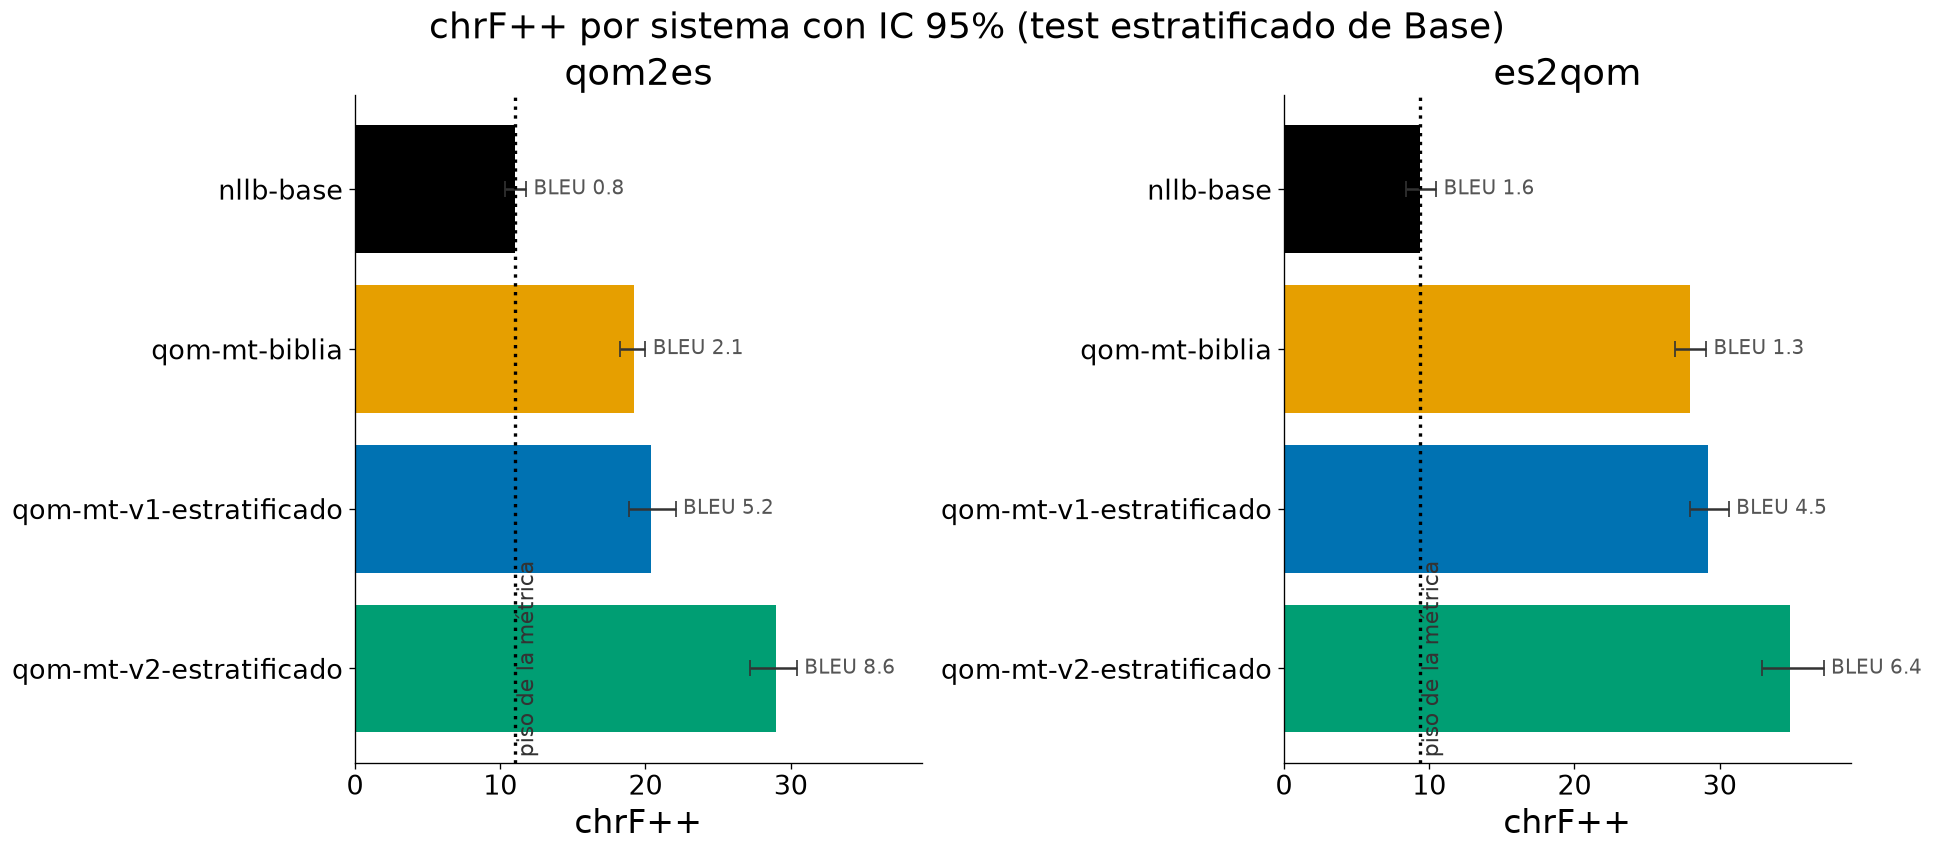

In [28]:
# ── Figura A: chrF++ con IC 95% por sistema, un panel por dirección ───────────
# Para la figura principal preferimos las variantes ESTRATIFICADAS donde existan.
def solo_estrat(df):
    return df[~df["system"].str.contains("aleatorio", na=False)]

bleu_lookup = metricas_corpus.set_index(["system", "direction"])["bleu"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
for ax, direccion in zip(axes, ["qom2es", "es2qom"]):
    d = solo_estrat(ic_sistemas[ic_sistemas["direction"] == direccion]).copy()
    orden = [s for s in SISTEMAS_ORDEN if s in set(d["system"])]
    d = d.set_index("system").loc[orden].reset_index()
    if d.empty:
        ax.set_visible(False)
        continue
    y = np.arange(len(d))
    err = np.vstack([d["chrf_pp"] - d["ic_low"], d["ic_high"] - d["chrf_pp"]])
    colores = [COLOR_SISTEMA.get(s, OKABE_ITO["violeta"]) for s in d["system"]]
    ax.barh(y, d["chrf_pp"], xerr=err, color=colores, capsize=5,
            error_kw=dict(ecolor="#333333", lw=1.5))
    ax.set_yticks(y); ax.set_yticklabels(d["system"]); ax.invert_yaxis()
    ax.set_title(direccion); ax.set_xlabel("chrF++")

    base = d[d["system"] == "nllb-base"]
    if len(base):
        ax.axvline(base["chrf_pp"].iloc[0], ls=":", color=OKABE_ITO["negro"], lw=2)
        ax.text(base["chrf_pp"].iloc[0], len(d) - 0.4, " piso de la métrica",
                rotation=90, va="bottom", ha="left", fontsize=13, color="#333333")
    for yi, (_, row) in zip(y, d.iterrows()):
        b = bleu_lookup.get((row["system"], direccion))
        if b is not None:
            ax.text(row["chrf_pp"] + err[1][yi] + 0.5, yi, f"BLEU {b:.1f}",
                    va="center", fontsize=12, color="#555555")

fig.suptitle("chrF++ por sistema con IC 95% (test estratificado de Base)")
guardar(fig, "figuraA_chrf_ic")
plt.show()

In [29]:
# ── Tabla B: estratificado vs aleatorio, con contaminación ────────────────────
cont_lookup = (tabla_contaminacion.set_index("system")
               if len(tabla_contaminacion) else None)

filas_b = []
for base_sys in ["qom-mt-v1", "qom-mt-v2"]:
    for variante in ["estratificado", "aleatorio"]:
        sistema = f"{base_sys}-{variante}"
        for direccion in ["qom2es", "es2qom"]:
            fila = ic_sistemas[(ic_sistemas["system"] == sistema) &
                               (ic_sistemas["direction"] == direccion)]
            if fila.empty:
                continue
            r = fila.iloc[0]
            n_cont = np.nan
            if cont_lookup is not None and sistema in cont_lookup.index:
                n_cont = cont_lookup.loc[sistema, "contaminado_algun_nivel"]
            filas_b.append({"base": base_sys, "variante": variante, "direction": direccion,
                            "chrf_pp": r["chrf_pp"], "ic_low": r["ic_low"],
                            "ic_high": r["ic_high"], "items_contaminados": n_cont})

tabla_b = pd.DataFrame(filas_b).sort_values(["base", "direction", "variante"]) \
    if filas_b else pd.DataFrame()
if len(tabla_b):
    print(tabla_b.to_string(index=False))
    tabla_b.to_csv(RESULTS_DIR / "tablaB_estrat_vs_aleatorio.csv", index=False)
    variantes = set(tabla_b["variante"])
    if "aleatorio" not in variantes:
        print("\n[aviso] Todavía no hay variantes 'aleatorio' (nostrat) cargadas: la Tabla B "
              "queda incompleta. Generá qom-mt-v1-nostrat / qom-mt-v2-nostrat y volvé a correr.")
else:
    print("Sin datos para la Tabla B (faltan variantes v1/v2 sobre el test común).")

     base      variante direction  chrf_pp  ic_low  ic_high  items_contaminados
qom-mt-v1     aleatorio    es2qom    40.34   36.83    44.27                 270
qom-mt-v1 estratificado    es2qom    29.16   27.97    30.63                  22
qom-mt-v1     aleatorio    qom2es    30.32   28.38    32.46                 270
qom-mt-v1 estratificado    qom2es    20.40   18.89    22.08                  22
qom-mt-v2     aleatorio    es2qom    43.55   40.34    47.45                 315
qom-mt-v2 estratificado    es2qom    34.87   32.90    37.16                  47
qom-mt-v2     aleatorio    qom2es    42.08   39.06    46.07                 315
qom-mt-v2 estratificado    qom2es    28.95   27.18    30.43                  47


### Cierre

- La **métrica principal** es chrF++; BLEU se reporta pero no sostiene conclusiones (cerca
  de cero, en el zero-shot, no discrimina).
- Antes de leer cualquier ventaja, mirar la **Tabla B**: si una variante aleatoria "gana"
  pero tiene ítems contaminados, esa ventaja es solapamiento train/test, no calidad.
- Todos los números de las figuras están también en los CSV de `results/`.
- `chrf_por_segmento.csv` y `traducciones_tidy.csv` son la entrada de la **Notebook 2**.